In [ ]:
# -*- coding: utf-8 -*-
!pip install optuna tqdm scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.8 MB/s eta 0:00:00


In [ ]:
import os
# Desactivar compiladores dinámicos de PyTorch
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["PYTORCH_JIT_DISABLE"] = "1"

In [ ]:
import torch, pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
import optuna
from tqdm import tqdm


In [ ]:
# Archivos previamente guardados
with open("vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

X_train_tensor = torch.load("X_train.pt")
y_train_tensor = torch.load("y_train.pt")
X_test_tensor = torch.load("X_test.pt")
y_test_tensor = torch.load("y_test.pt")
embedding_matrix = torch.load("embedding_matrix.pt")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [ ]:
class BiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, embedding_matrix):
        super(BiGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = False
        self.bigru = nn.GRU(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, h = self.bigru(x)
        h_cat = torch.cat((h[0], h[1]), dim=1)
        return self.fc(h_cat)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128])
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    model = BiGRU(
        vocab_size=len(vocab),
        embed_dim=embedding_matrix.shape[1],
        hidden_dim=hidden_dim,
        num_classes=2,
        pad_idx=0,
        embedding_matrix=embedding_matrix
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Calcular pesos de clase según distribución real
    class_counts = torch.bincount(y_train_tensor)
    total = class_counts.sum().float()
    weights = total / class_counts.float()

    # Normalizar si lo deseas (opcional)
    weights = weights / weights.sum()

    # Definir la función de pérdida con pesos
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    for epoch in range(3):
        model.train()
        for X_batch, y_batch in tqdm(train_loader, desc=f"Trial {trial.number} Epoch {epoch+1} [Train]", leave=False, dynamic_ncols=True):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            _, predicted_val = torch.max(outputs_val, 1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(predicted_val.cpu().tolist())

    return f1_score(y_true, y_pred, average="macro")


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, n_jobs=1)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor F1 macro:", study.best_value)


[I 2026-06-13 03:33:43,403] A new study created in memory with name: no-name-367588e8-d200-4009-a8df-f16e4c607785
[I 2026-06-13 03:33:58,477] Trial 0 finished with value: 0.6475703989523875 and parameters: {'lr': 0.005750333840381362, 'hidden_dim': 128, 'batch_size': 64}. Best is trial 0 with value: 0.6475703989523875.
[I 2026-06-13 03:33:59,195] Trial 1 finished with value: 0.6214315414315414 and parameters: {'lr': 0.0003964590001153036, 'hidden_dim': 128, 'batch_size': 64}. Best is trial 0 with value: 0.6475703989523875.
[I 2026-06-13 03:34:00,559] Trial 2 finished with value: 0.6645310698727824 and parameters: {'lr': 0.00035602330087388, 'hidden_dim': 128, 'batch_size': 32}. Best is trial 2 with value: 0.6645310698727824.
[I 2026-06-13 03:34:00,985] Trial 3 finished with value: 0.6169564267876981 and parameters: {'lr': 0.0004418572029099884, 'hidden_dim': 128, 'batch_size': 64}. Best is trial 2 with value: 0.6645310698727824.
[I 2026-06-13 03:34:01,729] Trial 4 finished with value: 

Mejores hiperparámetros: {'lr': 0.007807623798492409, 'hidden_dim': 64, 'batch_size': 32}
Mejor F1 macro: 0.6976588628762541


In [ ]:
best_params = study.best_params
model = BiGRU(
    vocab_size=len(vocab),
    embed_dim=embedding_matrix.shape[1],
    hidden_dim=best_params["hidden_dim"],
    num_classes=2,
    pad_idx=0,
    embedding_matrix=embedding_matrix
).to(device)

optimizer = optim.Adam(model.parameters(), lr=best_params["lr"])

# Calcular pesos de clase según distribución real
class_counts = torch.bincount(y_train_tensor)
total = class_counts.sum().float()
weights = total / class_counts.float()
weights = weights / weights.sum()  # opcional normalización

criterion = nn.CrossEntropyLoss(weight=weights.to(device))


train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params["batch_size"])

best_val_f1 = 0
best_epoch = 0
patience = 3
epochs_no_improve = 0
max_epochs = 15

for epoch in range(max_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]", leave=True, dynamic_ncols=True):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    y_true, y_pred = [], []
    val_loss = 0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            loss_val = criterion(outputs_val, y_val)
            val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val, 1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(predicted_val.cpu().tolist())
    avg_val_loss = val_loss / len(test_loader)
    val_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val F1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_bigru.pt")
        print(f"Mejora detectada en epoch {epoch+1}, modelo guardado.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping activado")
            break

print(f"Entrenamiento final completo. Mejor F1 macro: {best_val_f1:.4f} en epoch {best_epoch}")


Epoch 1/15 [Train]: 100%|██████████| 85/85 [00:00<00:00, 105.45it/s]


Epoch 1: Train Loss=0.4535, Val Loss=0.4323, Val F1=0.6133
Mejora detectada en epoch 1, modelo guardado.


Epoch 2/15 [Train]: 100%|██████████| 85/85 [00:00<00:00, 224.19it/s]


Epoch 2: Train Loss=0.3843, Val Loss=0.4445, Val F1=0.6431
Mejora detectada en epoch 2, modelo guardado.


Epoch 3/15 [Train]: 100%|██████████| 85/85 [00:00<00:00, 221.07it/s]


...

Epoch 10: Train Loss=0.0618, Val Loss=0.8670, Val F1=0.7095


Epoch 11/15 [Train]: 100%|██████████| 85/85 [00:00<00:00, 344.58it/s]


Epoch 11: Train Loss=0.0293, Val Loss=1.0781, Val F1=0.7156


Epoch 12/15 [Train]: 100%|██████████| 85/85 [00:00<00:00, 358.41it/s]

Epoch 12: Train Loss=0.0110, Val Loss=1.1937, Val F1=0.7160
Early stopping activado
Entrenamiento final completo. Mejor F1 macro: 0.7270 en epoch 9


Evaluación inicial BiGRU (umbral estándar)
Matriz de confusión:
 [[441 112]
 [ 26  99]]
Exactitud (Accuracy): 0.7965

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.9443    0.7975    0.8647       553
           1     0.4692    0.7920    0.5893       125

    accuracy                         0.7965       678
   macro avg     0.7068    0.7947    0.7270       678
weighted avg     0.8567    0.7965    0.8139       678

ROC-AUC: 0.8685

Umbral óptimo según F1: 0.6400
Evaluación con umbral ajustado BiGRU
Matriz de confusión:
 [[452 101]
 [ 27  98]]
Exactitud (Accuracy): 0.8112

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.9436    0.8174    0.8760       553
           1     0.4925    0.7840    0.6049       125

    accuracy                         0.8112       678
   macro avg     0.7180    0.8007    0.7405       678
weighted avg     0.8605    0.8112    0.8260       678

ROC-AUC: 0.868

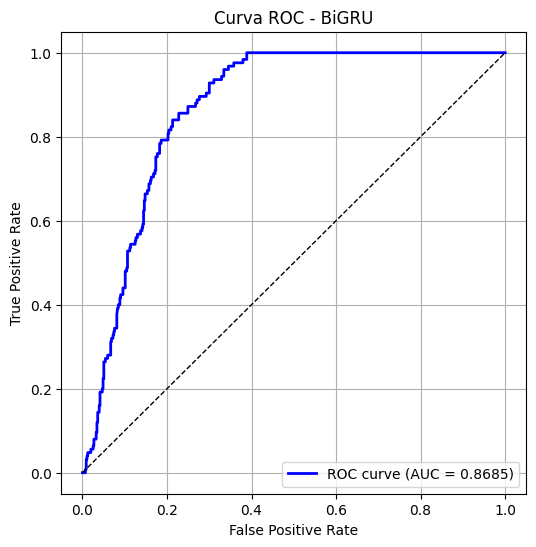

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Cargar mejor modelo entrenado
model.load_state_dict(torch.load("best_bigru.pt"))
model.eval()

# Obtener probabilidades de clase positiva
y_true, y_probs = [], []
with torch.no_grad():
    for X_val, y_val in test_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        outputs_val = model(X_val)
        probs = torch.softmax(outputs_val, dim=1)[:,1]  # probabilidad clase positiva
        y_true.extend(y_val.cpu().tolist())
        y_probs.extend(probs.cpu().tolist())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# --- Evaluación inicial (umbral estándar 0.5) ---
y_pred_default = (y_probs >= 0.5).astype(int)
cm_def = confusion_matrix(y_true, y_pred_default)
acc_def = (y_pred_default == y_true).mean()
print("Evaluación inicial BiGRU (umbral estándar)")
print("Matriz de confusión:\n", cm_def)
print(f"Exactitud (Accuracy): {acc_def:.4f}\n")
print("Reporte de clasificación:\n")
print(classification_report(y_true, y_pred_default, digits=4))
roc_auc = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC: {roc_auc:.4f}\n")

# --- Búsqueda de umbral óptimo según F1 ---
thresholds = np.linspace(0,1,201)
best_thr, best_f1 = 0.5, 0
for thr in thresholds:
    y_pred_thr = (y_probs >= thr).astype(int)
    f1_thr = f1_score(y_true, y_pred_thr, average="macro")
    if f1_thr > best_f1:
        best_f1 = f1_thr
        best_thr = thr
print(f"Umbral óptimo según F1: {best_thr:.4f}")

# --- Evaluación con umbral ajustado ---
y_pred_opt = (y_probs >= best_thr).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)
acc_opt = (y_pred_opt == y_true).mean()
print("Evaluación con umbral ajustado BiGRU")
print("Matriz de confusión:\n", cm_opt)
print(f"Exactitud (Accuracy): {acc_opt:.4f}\n")
print("Reporte de clasificación:\n")
print(classification_report(y_true, y_pred_opt, digits=4))
print(f"ROC-AUC: {roc_auc:.4f}\n")

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], color="black", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - BiGRU")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("curva_roc_bigru.png")
plt.show()
